# 02 · Visualize

Plots dispatch on what the data **is** — a curve, an image, a volume, a
correlation function — not on which instrument made it. A technique only
supplies axis captions and defaults.

In [1]:
from pathlib import Path

from NanoOrganizer import open_project
from NanoOrganizer.demo import demo_root

PROJECT = demo_root("DemoProject")

# attach=False: the micrographs were linked in 00 and are in the saved store.
# Re-attaching by folder convention would work here and would be the wrong
# habit — see the note at the top of 00.
wb = open_project(PROJECT, attach=False)
print(wb.summary())


DemoProject: 6 samples, 12 measurements (12 readable here, 0 not mounted).
Modalities: uvvis, tem
Root: /home/yuzhang/Repos/OrgDemo/DemoProject


## Curves

One curve per sample, for comparison.

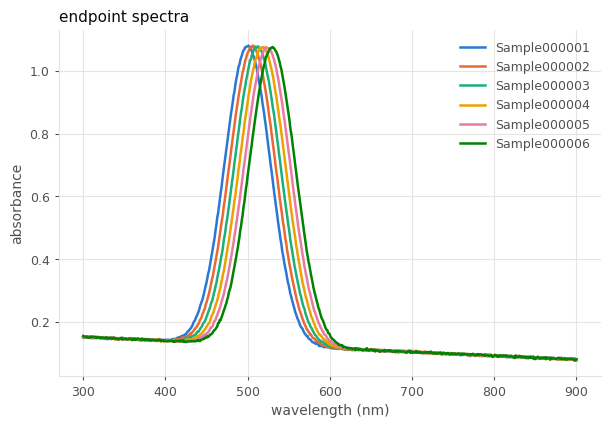

In [2]:
import matplotlib.pyplot as plt

wb.plot_overlay(modality="uvvis", stage="synthesis")
plt.show()

## One run in detail

Every frame of a single series, coloured light-to-dark by time. Only lightness
carries the ordering, so it survives greyscale and colour-blind viewing.

<FrameSeries 12 frames x 451 points, x=350..800, t=0..660 s from file>


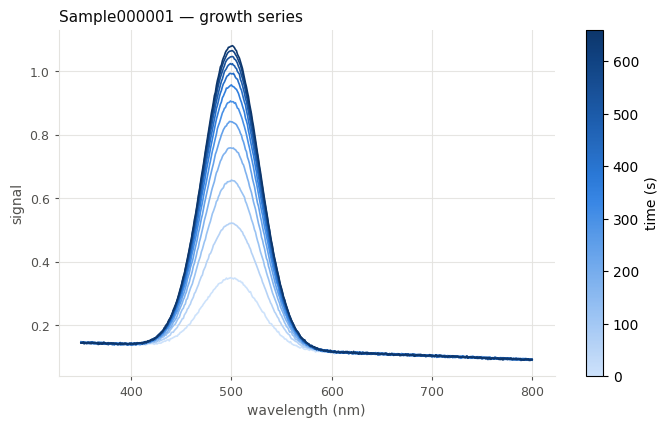

In [3]:
from NanoOrganizer.analysis import frames
from NanoOrganizer.viz import plots
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import numpy as np

m = wb.measurement("Sample000001", modality="uvvis")
series = frames.load_series(m, wb.resolver, crop=(350, 800))
print(series)

cmap, norm = plots.sequential_cmap(), Normalize(series.t_s.min(), series.t_s.max())
fig, ax = plt.subplots(figsize=(8, 4.5))
for i in range(len(series)):
    ax.plot(series.x, series.values[i], color=cmap(norm(series.t_s[i])), lw=1.2)
plots.style(ax, "wavelength (nm)", "signal", "Sample000001 — growth series")
fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="time (s)")
plt.show()

`FrameSeries` is the in-memory shape of any time-resolved 1D
measurement. `x`/`values` are the generic names; `wavelength`/`absorbance` are
aliases for when spectroscopy reads better.

In [4]:
print("band trace at 520 nm:", series.trace(520.0)[:4], "…")
print("cadence:", series.cadence_s, "s")
print("endpoint = mean of the last 60 s:", series.mean_between(
    series.t_s[-1] - 60, series.t_s[-1]).shape)

band trace at 520 nm: [0.29672312 0.42989916 0.53455417 0.61516931] …
cadence: 60.0 s
endpoint = mean of the last 60 s: (451,)


## Images

And always look at a segmentation before trusting a size distribution —
over-splitting and support texture both make a plausible histogram.

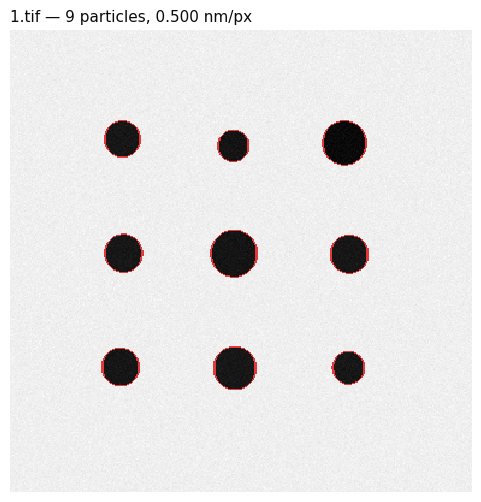

In [5]:
wb.plot_segmentation("Sample000006")
plt.show()